# Izhikevich Neuron Model

The Izhikevich model describes the dynamics of a spiking neuron using two variables:

- $v(t)$: membrane potential.
- $u(t)$: recovery variable.

The model equations are:

$$
\frac{dv}{dt} = 0.04v^2 + 5v + 140 - u + I
$$

$$
\frac{du}{dt} = a(bv-u)
$$

where $I$ is the total input current, including external noise and synaptic input from other neurons.

When the membrane potential reaches the firing threshold,

$$
v \geq 30
$$

the neuron emits a spike and is reset according to:

$$
v \leftarrow c
$$

$$
u \leftarrow u + d
$$

## Model variables

| Variable | Meaning |
|---|---|
| $$v$$ | Membrane potential. |
| $$u$$ | Recovery variable. |
| $$I$$ | Total input current. |
| $$a$$ | Recovery time scale. |
| $$b$$ | Sensitivity of $u$ to $v$. |
| $$c$$ | Reset value of $v$ after a spike. |
| $$d$$ | Increase of $u$ after a spike. |

## Network interpretation

The simulation contains excitatory and inhibitory neurons. Excitatory neurons have positive synaptic weights and tend to increase postsynaptic activity. Inhibitory neurons have negative synaptic weights and tend to suppress postsynaptic activity.

The global dynamics depend on the neuron parameters, the connectivity matrix, the synaptic weights, the external noise, and the balance between excitation and inhibition.

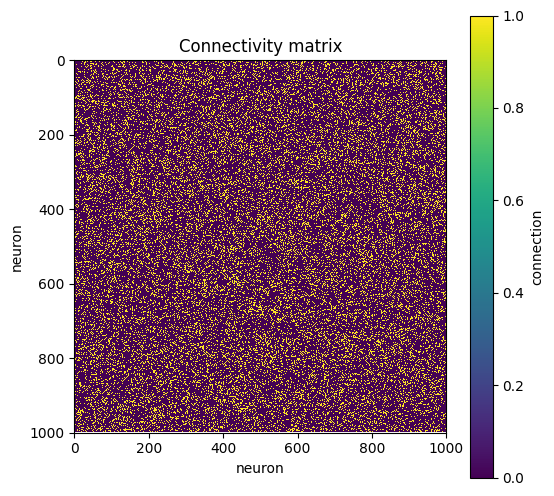

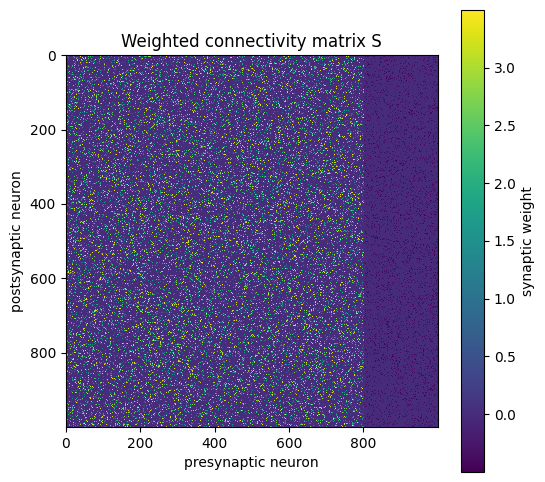

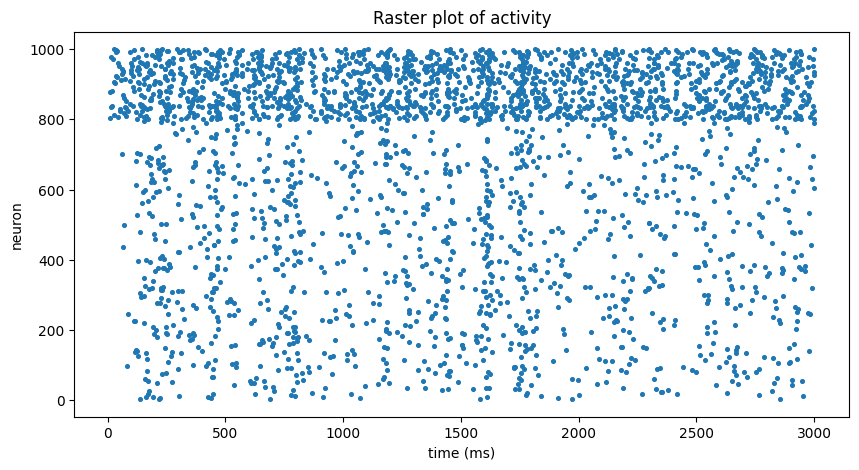

Fraction of active neurons per window:
[0.045 0.107 0.122 0.089 0.118 0.084 0.104 0.134 0.069 0.07 ]
Sync measure = 0.1340


In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# SET UP THE NETWORK
# ============================================================

# 1 - NETWORK SIZE
Ne = 800                  # Number of excitatory neurons
Ni = 200                  # Number of inhibitory neurons
N = Ne + Ni               # Total number of neurons
SIM_TIME = 3000           # Simulation time in ms

rng = np.random.default_rng()  # Random number generator


# ============================================================
# 2 - IZHIKEVICH NEURON PARAMETERS
# ============================================================

# Random variability between neurons
re = rng.random(Ne)
ri = rng.random(Ni)

# Izhikevich parameters
a = np.concatenate([
    0.02 * np.ones(Ne),
    0.02 + 0.08 * ri
])

b = np.concatenate([
    0.2 * np.ones(Ne),
    0.25 - 0.05 * ri
])

c = np.concatenate([
    -65 + 15 * re**2,
    -65 * np.ones(Ni)
])

d = np.concatenate([
    8 - 6 * re**2,
    2 * np.ones(Ni)
])


# ============================================================
# 3 - CONNECTIVITY MATRIX
# ============================================================

frac_delete = 0.80

# Random directed adjacency matrix
A = rng.random((N, N))

# Sparsify the graph
A[A < frac_delete] = 0
A[A > 0] = 1

# Remove self-connections
np.fill_diagonal(A, 0)

# Plot connectivity matrix
plt.figure(figsize=(6, 6))
plt.imshow(A, aspect="equal", interpolation="nearest")
plt.xlim([0, N])
plt.ylim([N, 0])
plt.xlabel("neuron")
plt.ylabel("neuron")
plt.title("Connectivity matrix")
plt.colorbar(label="connection")
plt.show()


# ============================================================
# 4 - SYNAPTIC WEIGHTS
# ============================================================

MAX_EXC_WEIGHT = 3.5
MAX_INH_WEIGHT = 0.5

# Columns 0,...,Ne-1 are excitatory presynaptic neurons
# Columns Ne,...,N-1 are inhibitory presynaptic neurons
W_exc = MAX_EXC_WEIGHT * rng.random((N, Ne))
W_inh = -MAX_INH_WEIGHT * rng.random((N, Ni))

W = np.hstack([W_exc, W_inh])

# Final directed weighted connectivity matrix
S = A * W

plt.figure(figsize=(6, 6))
plt.imshow(S, aspect="equal", interpolation="nearest")
plt.xlabel("presynaptic neuron")
plt.ylabel("postsynaptic neuron")
plt.title("Weighted connectivity matrix S")
plt.colorbar(label="synaptic weight")
plt.show()


# ============================================================
# 5 - NOISE STRENGTH
# ============================================================

NOISE_MAX = 3


# ============================================================
# MAIN SIMULATION
# ============================================================

# Initial membrane potentials
v = -65 * np.ones(N)

# Initial recovery variables
u = b * v

# List where we store spikes: each row will be [time, neuron_index]
firings = []

for t in range(1, SIM_TIME + 1):

    # External noisy input
    I = np.concatenate([
        NOISE_MAX * rng.standard_normal(Ne),
        2 * rng.standard_normal(Ni)
    ])

    # Find neurons that fired
    fired = np.where(v >= 30)[0]

    # Store spikes.
    # We add +1 to neuron indices to mimic MATLAB indexing.
    if fired.size > 0:
        firings.append(
            np.column_stack([
                np.full(fired.size, t),
                fired + 1
            ])
        )

    # Reset fired neurons
    v[fired] = c[fired]
    u[fired] += d[fired]

    # Add synaptic input from fired neurons
    if fired.size > 0:
        I += np.sum(S[:, fired], axis=1)

    # Numerical integration of the Izhikevich equations
    # Two half-steps of 0.5 ms for better numerical stability
    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)

    # Update recovery variable
    u += a * (b * v - u)


# Convert firings list to array
if len(firings) > 0:
    firings = np.vstack(firings)
else:
    firings = np.empty((0, 2))


# ============================================================
# RASTER PLOT
# ============================================================

plt.figure(figsize=(10, 5))
plt.scatter(firings[:, 0], firings[:, 1], s=7)
plt.xlabel("time (ms)")
plt.ylabel("neuron")
plt.title("Raster plot of activity")
plt.show()


# ============================================================
# SYNC MEASURE
# ============================================================

SYNC_TIME = 1000
WINDOW = 100
num_windows = SYNC_TIME // WINDOW

num_active = np.zeros(num_windows)

for j in range(num_windows):
    t_min = WINDOW * j
    t_max = WINDOW * (j + 1)

    # Spikes inside the current window
    mask = (firings[:, 0] >= t_min) & (firings[:, 0] <= t_max)
    firings_temp = firings[mask]

    neurons = firings_temp[:, 1]

    # Fraction of neurons that fired at least once in this window
    num_active[j] = len(np.unique(neurons)) / N

sync = np.max(num_active)

print("Fraction of active neurons per window:")
print(num_active)

print(f"Sync measure = {sync:.4f}")